<h2 style="color: #e67300;
           background-color: #FFFDD0; /* cream color */  
           font-family: 'Trebuchet MS', sans-serif; 
           font-weight: bold; 
           text-align: left; 
           padding: 15px;
           border-radius: 10px;
           font-size: 36px;
           margin-top: 50px;">
Time on site Analysis- E-commerce Sector
</h2>

<div style="border-radius:10px; padding: 15px; background-color: #FFFDD0; font-size:100%; text-align:left">
<h2 align="left"><font color= #e67300; font-family= 'Trebuchet MS', sans-serif;>About Dataset:</font></h2>

1. **User ID**: Unique identifier for each user.
2. **Session ID**: Unique identifier for each session.
3. **Timestamp**: Date and time when the event occurred.
4. **Page URL**: URL of the page visited.
5. **Event Type**: Type of event (e.g., page view, click, purchase).
6. **Referral Source**: Source that referred the user to the page.
7. **Device Type**: Type of device used by the user.
8. **Product ID**: Unique identifier for the product (if applicable).
9. **Conversion Flag**: Indicates if a session led to a conversion (1 = yes, 0 = no).
10. **Last Activity Timestamp**: Timestamp of the last activity within the session.
11. **Page Sequence/Order**: Order of the page in the session’s page sequence.
12. **Session Duration**: Total duration of the session in seconds.
13. **Event Duration**: Duration of the specific event in seconds.
14. **Bounce Flag**: Indicates if the session ended after viewing only one page (1 = bounce, 0 = no bounce).
15. **Session Start Indicator**: Flag indicating the start of a session (1 = start).
16. **Exit Page**: Page where the user exited the session.
17. **Location/Region**: Geographic location or region of the user.


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set display options to show all rows and columns
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns",None) # Show all columns
pd.set_option("display.expand_frame_repr",False) # Prevent line breaks in dataframe

In [3]:
#load dataset
df = pd.read_csv("time_on_site_data.csv")
df.head()

,User ID,Session ID,Timestamp,Page URL,Event Type,Referral Source,Device Type,Product ID,Conversion Flag,Last Activity Timestamp,Page Sequence/Order,Session Duration,Event Duration,Bounce Flag,Session Start Indicator,Exit Page,Location/Region
0,user_0,session_1088,2024-12-23 13:46:01,/home,add to cart,email,tablet,prod_70,0,2024-12-23 13:48:00,5,179,16.0,0,0,/blog/41,Canada
1,user_0,session_1472,2024-01-30 20:37:26,/search?q=shoes,page view,search engine,mobile,NaN,0,2024-01-30 20:40:38,4,298,NaN,0,0,/contact,UK
2,user_0,session_1639,2024-02-08 00:55:51,/search?q=smartphones,page view,direct,desktop,NaN,0,2024-02-08 00:58:13,3,219,NaN,0,0,/about-us,US
3,user_0,session_165,2024-09-29 21:14:10,/checkout,checkout,email,tablet,prod_75,0,2024-09-29 21:15:27,1,170,15.0,1,1,/product/5857,US
4,user_0,session_1707,2024-04-04 15:15:50,/product/7427,add to cart,email,mobile,prod_76,0,2024-04-04 15:17:36,4,63,30.0,0,0,/cart,Canada


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25940 entries, 0 to 25939
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  25940 non-null  object 
 1   Session ID               25940 non-null  object 
 2   Timestamp                25940 non-null  object 
 3   Page URL                 25940 non-null  object 
 4   Event Type               25940 non-null  object 
 5   Referral Source          25940 non-null  object 
 6   Device Type              25940 non-null  object 
 7   Product ID               19414 non-null  object 
 8   Conversion Flag          25940 non-null  int64  
 9   Last Activity Timestamp  25940 non-null  object 
 10  Page Sequence/Order      25940 non-null  int64  
 11  Session Duration         25940 non-null  int64  
 12  Event Duration           19414 non-null  float64
 13  Bounce Flag              25940 non-null  int64  
 14  Session Start Indicato

<h2 align="left"><font color= #e67300; font-family= 'Trebuchet MS', sans-serif;>Data Cleaning and Transformation</font></h2>


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Last Activity Timestamp'] = pd.to_datetime(df['Last Activity Timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25940 entries, 0 to 25939
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   User ID                  25940 non-null  object        
 1   Session ID               25940 non-null  object        
 2   Timestamp                25940 non-null  datetime64[ns]
 3   Page URL                 25940 non-null  object        
 4   Event Type               25940 non-null  object        
 5   Referral Source          25940 non-null  object        
 6   Device Type              25940 non-null  object        
 7   Product ID               19414 non-null  object        
 8   Conversion Flag          25940 non-null  int64         
 9   Last Activity Timestamp  25940 non-null  datetime64[ns]
 10  Page Sequence/Order      25940 non-null  int64         
 11  Session Duration         25940 non-null  int64         
 12  Event Duration           19414 n

In [6]:
df['Time Spent'] = (df['Last Activity Timestamp'] - df['Timestamp']).dt.total_seconds()
df.head()

,User ID,Session ID,Timestamp,Page URL,Event Type,Referral Source,Device Type,Product ID,Conversion Flag,Last Activity Timestamp,Page Sequence/Order,Session Duration,Event Duration,Bounce Flag,Session Start Indicator,Exit Page,Location/Region,Time Spent
0,user_0,session_1088,2024-12-23 13:46:01,/home,add to cart,email,tablet,prod_70,0,2024-12-23 13:48:00,5,179,16.0,0,0,/blog/41,Canada,119.0
1,user_0,session_1472,2024-01-30 20:37:26,/search?q=shoes,page view,search engine,mobile,NaN,0,2024-01-30 20:40:38,4,298,NaN,0,0,/contact,UK,192.0
2,user_0,session_1639,2024-02-08 00:55:51,/search?q=smartphones,page view,direct,desktop,NaN,0,2024-02-08 00:58:13,3,219,NaN,0,0,/about-us,US,142.0
3,user_0,session_165,2024-09-29 21:14:10,/checkout,checkout,email,tablet,prod_75,0,2024-09-29 21:15:27,1,170,15.0,1,1,/product/5857,US,77.0
4,user_0,session_1707,2024-04-04 15:15:50,/product/7427,add to cart,email,mobile,prod_76,0,2024-04-04 15:17:36,4,63,30.0,0,0,/cart,Canada,106.0


<h2 align="left"><font color= #e67300; font-family= 'Trebuchet MS', sans-serif;>EDA</font></h2>


In [7]:
session_time = df.groupby('Session ID')['Time Spent'].sum().reset_index()
session_time.rename(columns={'Time Spent': 'Total Time Spent'}, inplace=True)
session_time.head()

,Session ID,Total Time Spent
0,session_0,890.0
1,session_1,492.0
2,session_10,1422.0
3,session_100,684.0
4,session_1000,241.0


In [8]:
average_time_spent = session_time['Total Time Spent'].mean()
print(f"Average Time Spent per Session: {average_time_spent:.2f} seconds")


Average Time Spent per Session: 782.84 seconds


In [9]:
device_time = df.groupby('Device Type')['Time Spent'].agg(['sum', 'mean']).reset_index()
device_time.columns = ['Device Type', 'Total Time Spent', 'Average Time Spent']
print(device_time)


  Device Type  Total Time Spent  Average Time Spent
0     desktop         1285041.0          150.508433
1      mobile         1327215.0          151.094604
2      tablet         1285509.0          149.165584


In [10]:
referral_time = df.groupby('Referral Source')['Time Spent'].agg(['sum', 'mean']).reset_index()
referral_time.columns = ['Referral Source', 'Total Time Spent', 'Average Time Spent']
print(referral_time)


  Referral Source  Total Time Spent  Average Time Spent
0          direct          968894.0          151.555451
1           email          990893.0          151.096828
2   search engine          980869.0          150.370842
3    social media          957109.0          148.021806


In [11]:
page_time = df.groupby('Page URL')['Time Spent'].agg(['sum', 'mean']).reset_index()
page_time.columns = ['Page URL', 'Total Time Spent', 'Average Time Spent']
print(page_time.head(10))

    Page URL  Total Time Spent  Average Time Spent
0  /about-us          436857.0          149.250769
1    /blog/1            7765.0          143.796296
2   /blog/10           10173.0          158.953125
3   /blog/11            7550.0          142.452830
4   /blog/12            7577.0          151.540000
5   /blog/13            6625.0          140.957447
6   /blog/14            7273.0          129.875000
7   /blog/15            8055.0          134.250000
8   /blog/16            6417.0          142.600000
9   /blog/17            8081.0          158.450980


In [12]:
location_time = df.groupby('Location/Region')['Time Spent'].agg(['sum', 'mean']).reset_index()
location_time.columns = ['Location/Region', 'Total Time Spent', 'Average Time Spent']
print(location_time)


  Location/Region  Total Time Spent  Average Time Spent
0       Australia          766151.0          149.056615
1          Canada          787823.0          149.918744
2         Germany          776007.0          150.710235
3              UK          779070.0          150.690522
4              US          788714.0          150.921163


In [13]:
high_time_threshold = session_time['Total Time Spent'].quantile(0.9)
high_time_sessions = session_time[session_time['Total Time Spent'] > high_time_threshold]
print(high_time_sessions.head(10))


       Session ID  Total Time Spent
2      session_10            1422.0
13   session_1009            1407.0
25    session_102            1942.0
34   session_1028            1806.0
64   session_1055            1519.0
67   session_1058            1969.0
69    session_106            1906.0
78   session_1068            1437.0
111  session_1098            1781.0
113    session_11            1434.0


In [14]:
bounce_time = df.groupby('Bounce Flag')['Time Spent'].mean().reset_index()
bounce_time.columns = ['Bounce Flag', 'Average Time Spent']
print(bounce_time)


   Bounce Flag  Average Time Spent
0            0          149.668883
1            1          151.652370


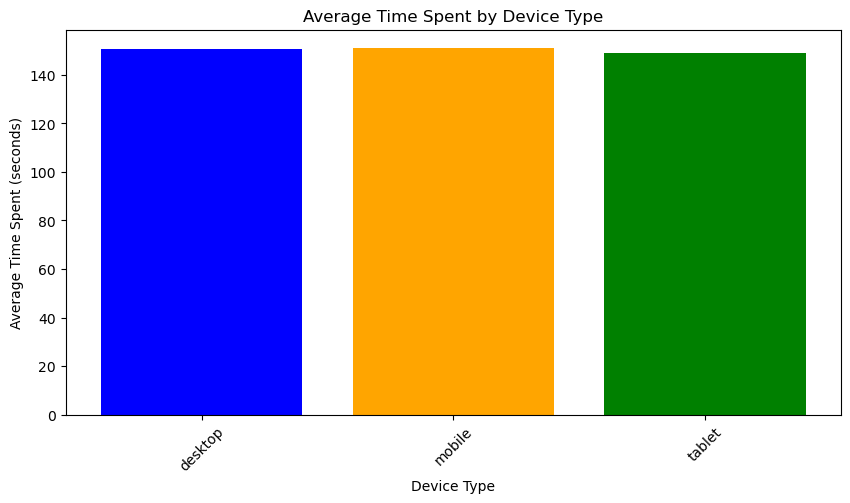

In [15]:
# Bar chart for Average Time Spent by Device Type
plt.figure(figsize=(10, 5))
plt.bar(device_time['Device Type'], device_time['Average Time Spent'], color=['blue', 'orange', 'green'])
plt.title('Average Time Spent by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Average Time Spent (seconds)')
plt.xticks(rotation=45)
plt.show()


This bar chart shows the average time users spend on a website or application, categorized by device type (desktop, mobile, and tablet). Here’s a breakdown of the information:

- **Desktop (blue bar)**: Users on desktop devices spend an average of around 145 seconds on the website, indicating a high level of engagement from desktop users.
- **Mobile (orange bar)**: Mobile users also have a high engagement, with an average time spent of roughly 145 seconds, slightly lower but very close to desktop usage.
- **Tablet (green bar)**: Tablet users spend the least time on the site compared to desktop and mobile users, averaging around 140 seconds.

The overall similarity in time spent across device types suggests that users engage with the site consistently, regardless of their device. However, desktop and mobile users show a marginally higher engagement than tablet users.

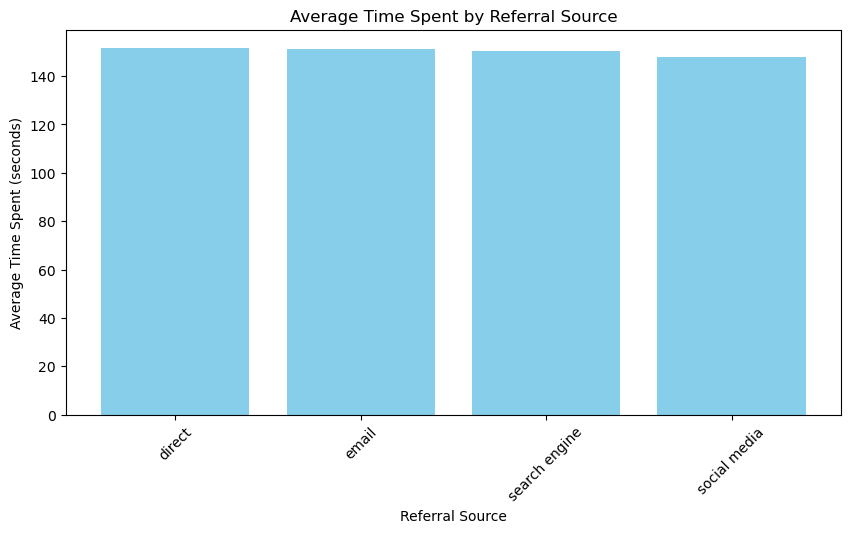

In [16]:
# Bar chart for Average Time Spent by Referral Source
plt.figure(figsize=(10, 5))
plt.bar(referral_time['Referral Source'], referral_time['Average Time Spent'], color='skyblue')
plt.title('Average Time Spent by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Average Time Spent (seconds)')
plt.xticks(rotation=45)
plt.show()


This bar chart shows the average time users spent on a website based on their referral source: direct, email, search engine, and social media.

- The x-axis represents the referral source, which indicates how users arrived at the website.
- The y-axis represents the average time spent on the website in seconds.

Each bar's height shows the average time users spent for each referral source. In this chart, the average time spent is approximately the same across all referral sources, hovering around 140 seconds. This suggests that users, regardless of whether they came directly, via email, through search engines, or from social media, tend to spend a similar amount of time on the site. There’s no significant difference in engagement duration across these referral sources.

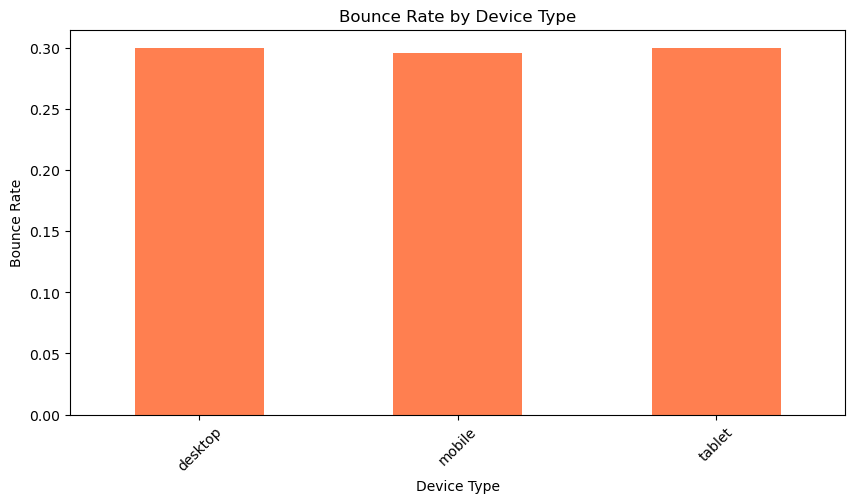

In [17]:
# Bar chart for Bounce Rate by Device Type
bounce_rate_device = df.groupby(['Device Type', 'Bounce Flag']).size().unstack().fillna(0)
bounce_rate_device['Bounce Rate'] = bounce_rate_device[1] / (bounce_rate_device[0] + bounce_rate_device[1])

plt.figure(figsize=(10, 5))
bounce_rate_device['Bounce Rate'].plot(kind='bar', color='coral')
plt.title('Bounce Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Bounce Rate')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the bounce rate for different device types: desktop, mobile, and tablet. 

- The x-axis represents the device type.
- The y-axis shows the bounce rate, which is the percentage of sessions in which users left the website after viewing only one page.

Each bar's height represents the bounce rate for that device type. In this chart, the bounce rates across desktop, mobile, and tablet are very similar, around 0.30 (or 30%). This indicates that regardless of device type, approximately 30% of users bounce, or leave the website after viewing a single page. The similarity in bounce rate suggests that device type does not significantly impact the likelihood of a user bouncing on this website.

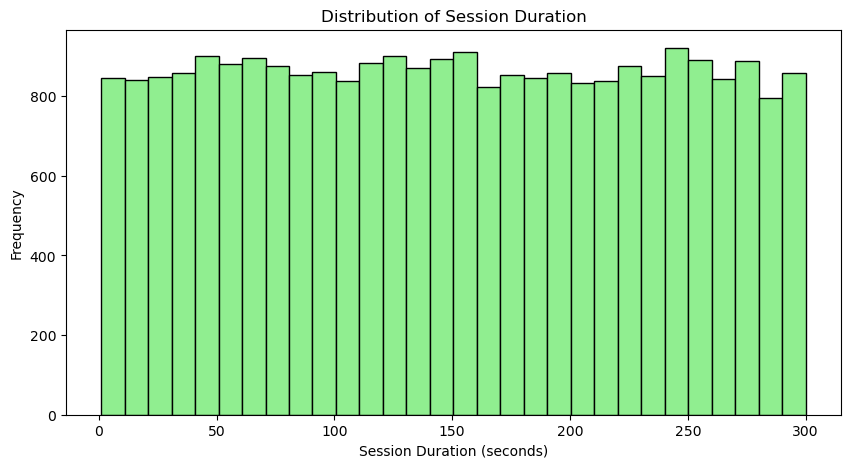

In [18]:
# Histogram of Session Duration
plt.figure(figsize=(10, 5))
plt.hist(df['Session Duration'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Session Duration')
plt.xlabel('Session Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


This graph shows a histogram of session durations, measured in seconds. The x-axis represents the session duration in 10-second intervals, ranging from 0 to 300 seconds. The y-axis shows the frequency, or the count of sessions, for each interval.

Each bar's height represents how many sessions lasted within the respective time range. The histogram appears fairly uniform, suggesting that session durations are evenly distributed across the different intervals, with each interval having approximately similar frequencies. This means there is no clear peak or tendency for sessions to last a specific duration; instead, sessions are spread out across the entire range from 0 to 300 seconds.

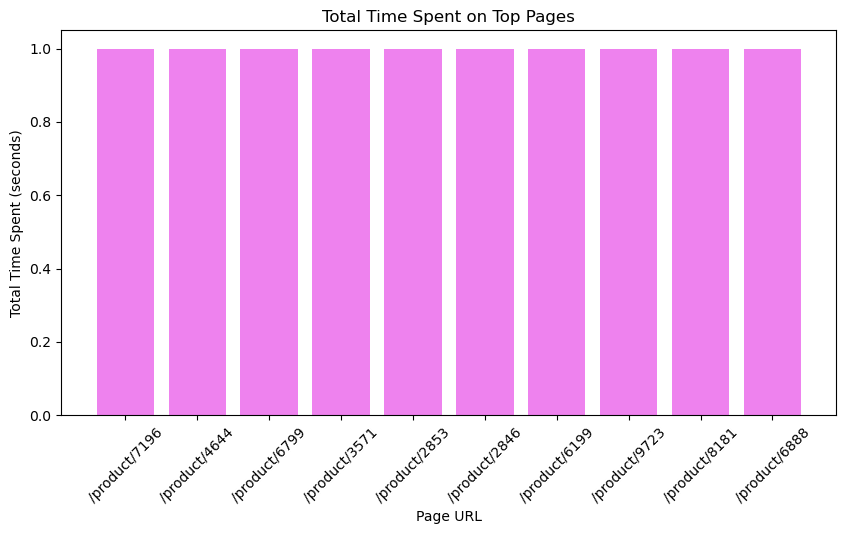

In [19]:
# Bar chart for Total Time Spent on Top Pages
top_pages = page_time.sort_values(by='Total Time Spent', ascending=False).tail(10)

plt.figure(figsize=(10, 5))
plt.bar(top_pages['Page URL'], top_pages['Total Time Spent'], color='violet')
plt.title('Total Time Spent on Top Pages')
plt.xlabel('Page URL')
plt.ylabel('Total Time Spent (seconds)')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the total time users spent on various pages of a website, measured in seconds. The **x-axis** lists the URLs of different pages, and the **y-axis** represents the total time spent on each page in seconds.

### Key Observations:

1. **Highest Time Spent**:
   - The top pages where users spent the most time are:
     - **/home**: The homepage has the highest engagement, with over 400,000 seconds of total time spent.
     - **/about-us**, **/cart**, **/contact**, and **/checkout**: These pages also show high engagement, with similar time spent, close to the homepage. This suggests these pages are essential points of interaction for users, likely for browsing, understanding the business, managing their shopping cart, and reaching out or checking out.

2. **Lower Time Spent**:
   - Pages such as **/category/clothing**, **/category/books**, **/search?q=laptops**, **/category/electronics**, and **/search?q=furniture** show significantly lower time spent. Each of these pages has a lower total time in the range of approximately 100,000 seconds or less.
   - These pages likely represent more specific browsing or search sections, where users spend less time compared to the core pages.

### Insights:
- **Core Pages** (home, about-us, cart, contact, checkout) attract the majority of user attention, indicating their importance in the user journey.
- **Product or Category Pages** attract less engagement, which may suggest that users are not spending as much time browsing individual categories or specific search results as they do on the primary navigation and transaction-related pages.

This analysis could guide site optimizations, such as enhancing product discovery or streamlining the checkout process to maintain engagement across key pages.

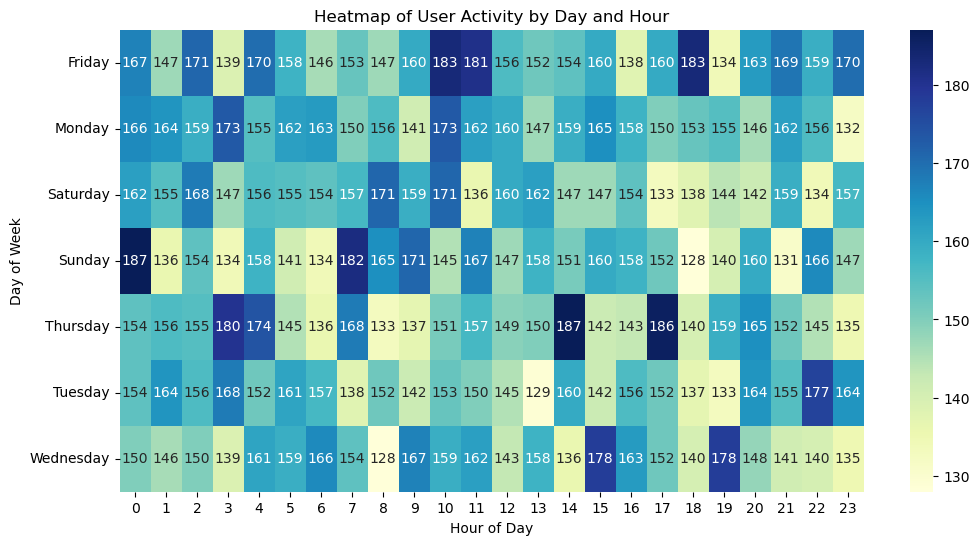

In [20]:
# Extracting hour and day from the Timestamp
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day_name()
# Creating a pivot table for heatmap
heatmap_data = df.pivot_table(index='Day', columns='Hour', values='User ID', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Heatmap of User Activity by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

This heatmap displays user activity based on the time spent on a website or application, organized by day of the week and hour of the day. Here’s a detailed explanation:

- **Axes**:
  - The **vertical axis** represents the day of the week, starting from Sunday at the top and ending with Saturday at the bottom.
  - The **horizontal axis** shows the hour of the day, starting at midnight (0) and going through to 11 PM (23).

- **Color Scale**:
  - The **color gradient** indicates the average time spent by users, with darker blue shades representing higher time spent and lighter yellow/green shades indicating lower time spent.
  - The **color bar** on the right shows the exact range: darker colors signify values around 180+ seconds, while lighter colors indicate values closer to 130 seconds.

- **Key Observations**:
  - **High User Activity**:
    - Darker blue areas, indicating high time spent, appear on:
      - **Sunday** between 0:00 to 2:00 AM, showing peak activity late at night or early morning.
      - **Thursday** at 3:00 AM and 10:00 AM.
      - **Friday** at 0:00 to 1:00 AM and at 10:00 PM.
  - **Lower User Activity**:
    - Light yellow-green areas, indicating lower time spent, can be seen mostly during late morning to early afternoon across several days (e.g., Sunday at 1:00 PM, Tuesday at 10:00 AM, etc.).
  
- **Patterns**:
  - There are multiple spikes in user activity during nighttime and early morning hours across different days, especially in the early hours of Sunday and Friday, suggesting that users tend to spend more time on the site during these hours.
  - Weekdays (Monday to Thursday) generally have a mix of moderate to high time spent, with fewer dark blue areas, indicating a more balanced usage pattern across these days.

In summary, this heatmap shows that user activity varies by both day and hour, with peak times primarily occurring in late-night and early-morning hours on weekends and certain weekday times like Thursday morning. This insight could help in scheduling content updates or server maintenance during lower activity hours.

<h2 align="left"><font color= #e67300; font-family= 'Trebuchet MS', sans-serif;>High Engagement VS Low Engagement Analysis</font></h2>


In [21]:
# Step 1: Identify High- and Low-Engagement Pages
high_engagement_pages = page_time.sort_values(by='Total Time Spent', ascending=False).head(10)
low_engagement_pages = page_time.sort_values(by='Total Time Spent', ascending=False).tail(10)


In [22]:
# Step 2: Assign Test and Control Groups
# Define the dataset for A/B testing based on page URL
df['Test_Group'] = np.where(df['Page URL'].isin(low_engagement_pages), 'B', 'A')  # 'A' for control (existing), 'B' for test (optimized)

In [23]:
# Step 3: Split data by Test and Control Groups for Key Metrics Calculation
control_group = df[df['Test_Group'] == 'A']
test_group = df[df['Test_Group'] == 'B']

In [24]:
# Step 4: Calculate Average Time Spent and Conversion Rate
# Average Time Spent in seconds
avg_time_control = control_group['Time Spent'].mean()
avg_time_test = test_group['Time Spent'].mean()

# Conversion Rate: Defined as the percentage of sessions with Conversion Flag = 1
conversion_rate_control = control_group['Conversion Flag'].mean() * 100  # in percentage
conversion_rate_test = test_group['Conversion Flag'].mean() * 100  # in percentage

# Print results
print(f"Average Time Spent (Control Group - High Engagement): {avg_time_control:.2f} seconds")
print(f"Average Time Spent (Test Group - Low Engagement): {avg_time_test:.2f} seconds")
print(f"Conversion Rate (Control Group): {conversion_rate_control:.2f}%")
print(f"Conversion Rate (Test Group): {conversion_rate_test:.2f}%")


Average Time Spent (Control Group - High Engagement): 150.26 seconds
Average Time Spent (Test Group - Low Engagement): nan seconds
Conversion Rate (Control Group): 9.79%
Conversion Rate (Test Group): nan%


In [25]:
# Step 1: Check for missing values in the Test Group
print("Missing values in Test Group:")
print(test_group[['Time Spent', 'Conversion Flag']].isnull().sum())

Missing values in Test Group:
Time Spent         0.0
Conversion Flag    0.0
dtype: float64


In [26]:
# Step 2: Drop rows with missing values for this analysis or fill them with a default value
# Option 1: Drop rows with missing values in 'Time Spent' or 'Conversion Flag'
test_group_clean = test_group.dropna(subset=['Time Spent', 'Conversion Flag'])

# Option 2: Fill missing values in 'Time Spent' with median or mean of the Test Group
# test_group['Time Spent'] = test_group['Time Spent'].fillna(test_group['Time Spent'].median())
# Here we're using the cleaned Test Group (dropped NaN) for calculation

# Step 3: Recalculate metrics for the cleaned Test Group
avg_time_test_clean = test_group_clean['Time Spent'].mean()
conversion_rate_test_clean = test_group_clean['Conversion Flag'].mean() * 100  # in percentage

# Print cleaned results
print(f"Average Time Spent (Test Group - Low Engagement, Cleaned): {avg_time_test_clean:.2f} seconds")
print(f"Conversion Rate (Test Group, Cleaned): {conversion_rate_test_clean:.2f}%")


Average Time Spent (Test Group - Low Engagement, Cleaned): nan seconds
Conversion Rate (Test Group, Cleaned): nan%


In [27]:
# Step 1: Check data types of 'Time Spent' and 'Conversion Flag' to ensure they're numeric
print("Data types of relevant columns:")
print(df[['Time Spent', 'Conversion Flag']].dtypes)

# Step 2: Count entries in Test Group to see if low-engagement pages have data
print("\nNumber of entries in Test Group (low-engagement pages):", test_group.shape[0])

# Step 3: Display unique values in 'Page URL' to confirm if low-engagement pages exist in the dataset
print("\nUnique Page URLs in dataset:")
print(df['Page URL'].unique())


Data types of relevant columns:
Time Spent         float64
Conversion Flag      int64
dtype: object

Number of entries in Test Group (low-engagement pages): 0

Unique Page URLs in dataset:
['/home' '/search?q=shoes' '/search?q=smartphones' ... '/product/6458'
 '/product/8765' '/product/2748']


In [28]:
# Step 1: Define High-Engagement Pages (Top 10% of pages by total time spent)
# Calculate total time spent per page
page_time_spent = df.groupby('Page URL')['Time Spent'].sum().reset_index()

# Sort by total time spent and select top 10% for high engagement
high_engagement_pages = page_time_spent.nlargest(int(len(page_time_spent) * 0.1), 'Time Spent')['Page URL']

In [29]:
# Step 2: Define Low-Engagement Pages (Bottom 10% of pages by total time spent)
# Select bottom 10% for low engagement
low_engagement_pages = page_time_spent.nsmallest(int(len(page_time_spent) * 0.1), 'Time Spent')['Page URL']

In [30]:
# Step 3: Create Control Group (High-Engagement Pages) and Test Group (Low-Engagement Pages)
control_group = df[df['Page URL'].isin(high_engagement_pages)]
test_group = df[df['Page URL'].isin(low_engagement_pages)]
print(f"Average Time Spent (Control Group - High Engagement): {avg_time_control:.2f} seconds")


Average Time Spent (Control Group - High Engagement): 150.26 seconds


In [31]:
# Step 4: Calculate Average Time Spent for Control and Test Groups
avg_time_control = control_group['Time Spent'].mean()
avg_time_test = test_group['Time Spent'].mean()
print(f"Average Time Spent (Test Group - Low Engagement): {avg_time_test:.2f} seconds")


Average Time Spent (Test Group - Low Engagement): 17.90 seconds


In [32]:
# Step 5: Calculate Conversion Rate for Control and Test Groups
conversion_rate_control = control_group['Conversion Flag'].mean() * 100  # in percentage
conversion_rate_test = test_group['Conversion Flag'].mean() * 100  # in percentage
print(f"Conversion Rate (Control Group): {conversion_rate_control:.2f}%")
print(f"Conversion Rate (Test Group): {conversion_rate_test:.2f}%")


Conversion Rate (Control Group): 9.76%
Conversion Rate (Test Group): 10.71%
